### Overview
 * Author: AzG
 * Create Time: 2025-07-10 12:39:19
 * Modified by: AzG
 * Modified time: 2025-12-15 15:27:18
 * Description: Revised notebook documenting data transformation of design variables and predicted FoS into unified format for surrogate model training.

### Import packages and modules

In [1]:
from deepxtwin.surrogate import Designvars_FoS_Combiner
from pathlib import Path

### User INPUT

In [2]:
# Set project root folder path
PROJECT_ROOT = Path.cwd().parents[2]  
print(PROJECT_ROOT)

c:\Users\AzG\OneDrive - NGI\01_Projects\02_Campus_Ullevål\azure\sp14-wp4-deepxtwin


In [3]:
# INPUT: Specify parent folder path and child folder names carrying FoS data and design variables
designvars_folder_path = PROJECT_ROOT / "data"
fos_parent_folder_path = PROJECT_ROOT / "data" / "fos_results"

### Load Designvars and FoS data

In [4]:
# Generate Container object carrying design variables and calculation results
Combiner = Designvars_FoS_Combiner(
    designvars_folder_path, 
    fos_parent_folder_path
    )

In [5]:
# Load design vars
Combiner.load_designvars()
print(Combiner.design_vars_df)

c:\Users\AzG\OneDrive - NGI\01_Projects\02_Campus_Ullevål\azure\sp14-wp4-deepxtwin\data
       ribs                                                      Leire1  \
    su_clay   su_LC E_clay   E_LC  L_col  L_rib c_rib d_rib GURsUARatio   
0     33.80  231.18   6300  75000  16.17  24.64  1.30   0.6         700   
1     57.71  258.47   6300  75000  24.24  15.70  2.77   0.6         700   
2     26.62  259.01   6300  75000  20.82  24.69  2.86   0.6         700   
3     40.48  285.37   6300  75000  18.63  23.31  2.83   0.6         700   
4     64.58  228.68   6300  75000  21.01  15.39  2.43   0.6         700   
..      ...     ...    ...    ...    ...    ...   ...   ...         ...   
495   41.40  335.88   6300  75000  22.70  21.35  1.56   0.6         700   
496   30.51  304.83   6300  75000  19.95  24.76  1.35   0.6         700   
497   29.74  180.97   6300  75000  19.50  22.54  1.66   0.6         700   
498   44.41  236.27   6300  75000  18.17  26.13  1.95   0.6         700   
499   50.71 

In [15]:
Combiner.design_vars_df.describe()

ribs                                                      \
          su_clay      su_LC  E_clay     E_LC       L_col       L_rib   
count  500.000000  500.00000   500.0    500.0  500.000000  500.000000   
mean    41.997660  262.49842  6300.0  75000.0   19.749980   21.749580   
std     12.599047   50.57210     0.0      0.0    3.034711    4.190144   
min     16.330000  175.12000  6300.0  75000.0   14.500000   14.510000   
25%     33.037500  218.80500  6300.0  75000.0   17.127500   18.137500   
50%     40.225000  262.55000  6300.0  75000.0   19.755000   21.745000   
75%     48.980000  306.02250  6300.0  75000.0   22.372500   25.362500   
max    101.750000  349.76000  6300.0  75000.0   25.000000   28.970000   

                                     Leire1                    Leire2          \
            c_rib         d_rib GURsUARatio       gammaFC GURsUARatio gammaFC   
count  500.000000  5.000000e+02       500.0  5.000000e+02       500.0   500.0   
mean     2.000100  6.000000e-01       700.0  9.000000e-01       700.0     1.0   
std      0.577978  1.111335e-16         0.0  2.222670e-16         0.0     0.0   
min      1.000000  6.000000e-01       700.0  9.000000e-01       700.0     1.0   
25%      1.500000  6.000000e-01       700.0  9.000000e-01       700.0     1.0   
50%      2.000000  6.000000e-01       700.0  9.000000e-01       700.0     1.0   
75%      2.500000  6.000000e-01       700.0  9.000000e-01       700.0     1.0   
max      3.000000  6.000000e-01       700.0  9.000000e-01       700.0     1.0   

           Leire1      Leire2  
           sUARef      sUARef  
count  500.000000  500.000000  
mean    41.997660   41.997660  
std     12.599047   12.599047  
min     16.330000   16.330000  
25%     33.037500   33.037500  
50%     40.225000   40.225000  
75%     48.980000   48.980000  
max    101.750000  101.750000

In [ ]:
Combiner

In [7]:
# Load FoS data
Combiner.load_fos_all(fos_parent_folder_path, debug=True)
print(Combiner.fos_df)

# Print number of FoS identified as NaN values = did not converge
num_nan_col1 = Combiner.fos_df.iloc[:, 0].isna().sum()
num_nan_col2 = Combiner.fos_df.iloc[:, 1].isna().sum()
print(f"Number of NaN values in first column: {num_nan_col1}")
print(f"Number of NaN values in second column: {num_nan_col2}")

[    FoS interim   FoS end
0      1.354180  2.107225
1      2.044828  2.836594
2      1.306000  1.953000
3      1.644000  2.340000
4      2.201000  3.000000
5      1.541000  2.191000
6      1.780000  2.486000
7      1.459000  2.137000
8      1.673000  2.341000
9      1.713000  2.394000
10     1.976000  2.733000
11     1.898000  2.603000
12     1.466000  2.134000
13     1.007000  1.636000
14     0.930600       NaN
15     1.389000  2.033000
16     2.014000  2.855000
17     1.761000  2.592000
18     2.444000  3.242000
19     1.571000  2.251000
20     1.956000  2.774000
21     1.566000  2.230000
22     2.040000  2.736000
23     1.713000  2.433000
24     1.463000  2.112000
25     1.581000  2.262000
26     1.462000  2.122000
27     1.987000  2.652000
28     1.418000  2.101000
29     0.859000       NaN
30     1.456000  2.129000
31     2.523000  3.209000
32     1.990000  2.725000
33     1.754000  2.481000
34     1.157000  1.759000
35     1.339000  1.950000
36     1.271000  1.917000
37     1.56

In [8]:
# Hstack design vars and FoS data
Combiner.hstack_designvars_fos()
print(Combiner.combined_design_vars_fos_df.tail())

     ribs_su_clay  ribs_su_LC  ribs_E_clay  ribs_E_LC  ribs_L_col  ribs_L_rib  \
495         41.40      335.88         6300      75000       22.70       21.35   
496         30.51      304.83         6300      75000       19.95       24.76   
497         29.74      180.97         6300      75000       19.50       22.54   
498         44.41      236.27         6300      75000       18.17       26.13   
499         50.71      205.90         6300      75000       23.63       20.08   

     ribs_c_rib  ribs_d_rib  Leire1_GURsUARatio  Leire1_gammaFC  \
495        1.56         0.6                 700             0.9   
496        1.35         0.6                 700             0.9   
497        1.66         0.6                 700             0.9   
498        1.95         0.6                 700             0.9   
499        2.14         0.6                 700             0.9   

     Leire2_GURsUARatio  Leire2_gammaFC  Leire1_sUARef  Leire2_sUARef  \
495                 700             1

In [9]:
# Export data
Combiner.export_data()

### EDA

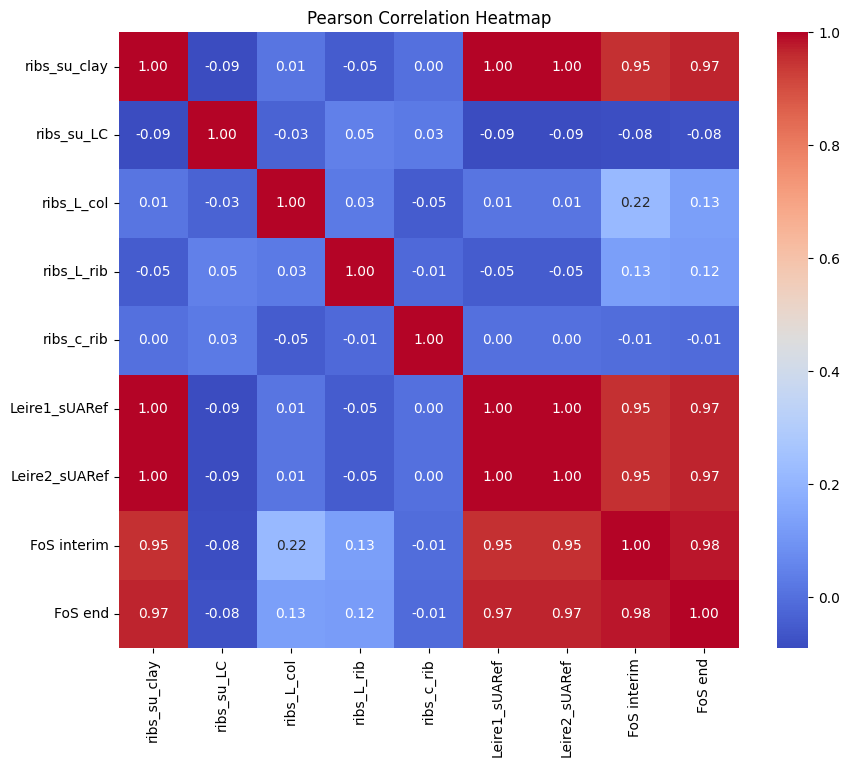

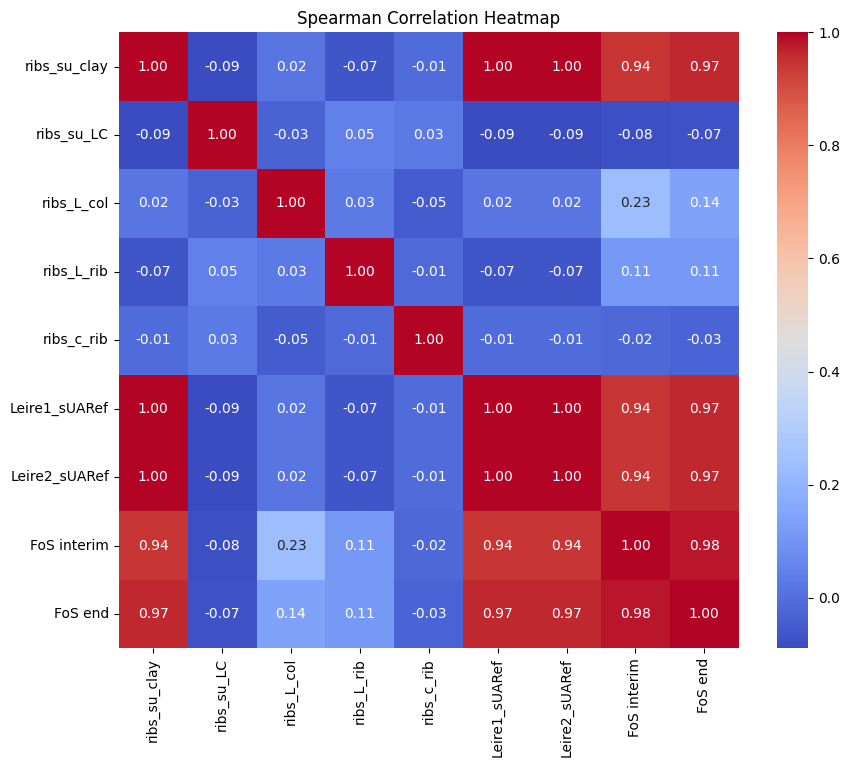

Overview of non-converged design variable sets:

     ribs_su_clay  ribs_su_LC  ribs_L_col  ribs_L_rib  ribs_c_rib  \
14          16.33      340.27       19.19       24.04        2.33   
29          19.00      290.34       16.39       18.73        1.10   
79          20.65      202.84       16.75       15.00        1.44   
120         22.70      312.01       15.29       21.55        1.76   
306         19.30      292.48       18.65       21.46        2.67   
341         19.87      284.35       14.74       24.73        2.51   
456         22.13      253.27       18.03       17.47        2.91   

     Leire1_sUARef  Leire2_sUARef  FoS interim  FoS end convergence_status  
14           16.33          16.33       0.9306      NaN      non-converged  
29           19.00          19.00       0.8590      NaN      non-converged  
79           20.65          20.65       0.8558      NaN      non-converged  
120          22.70          22.70       0.9740      NaN      non-converged  
306          

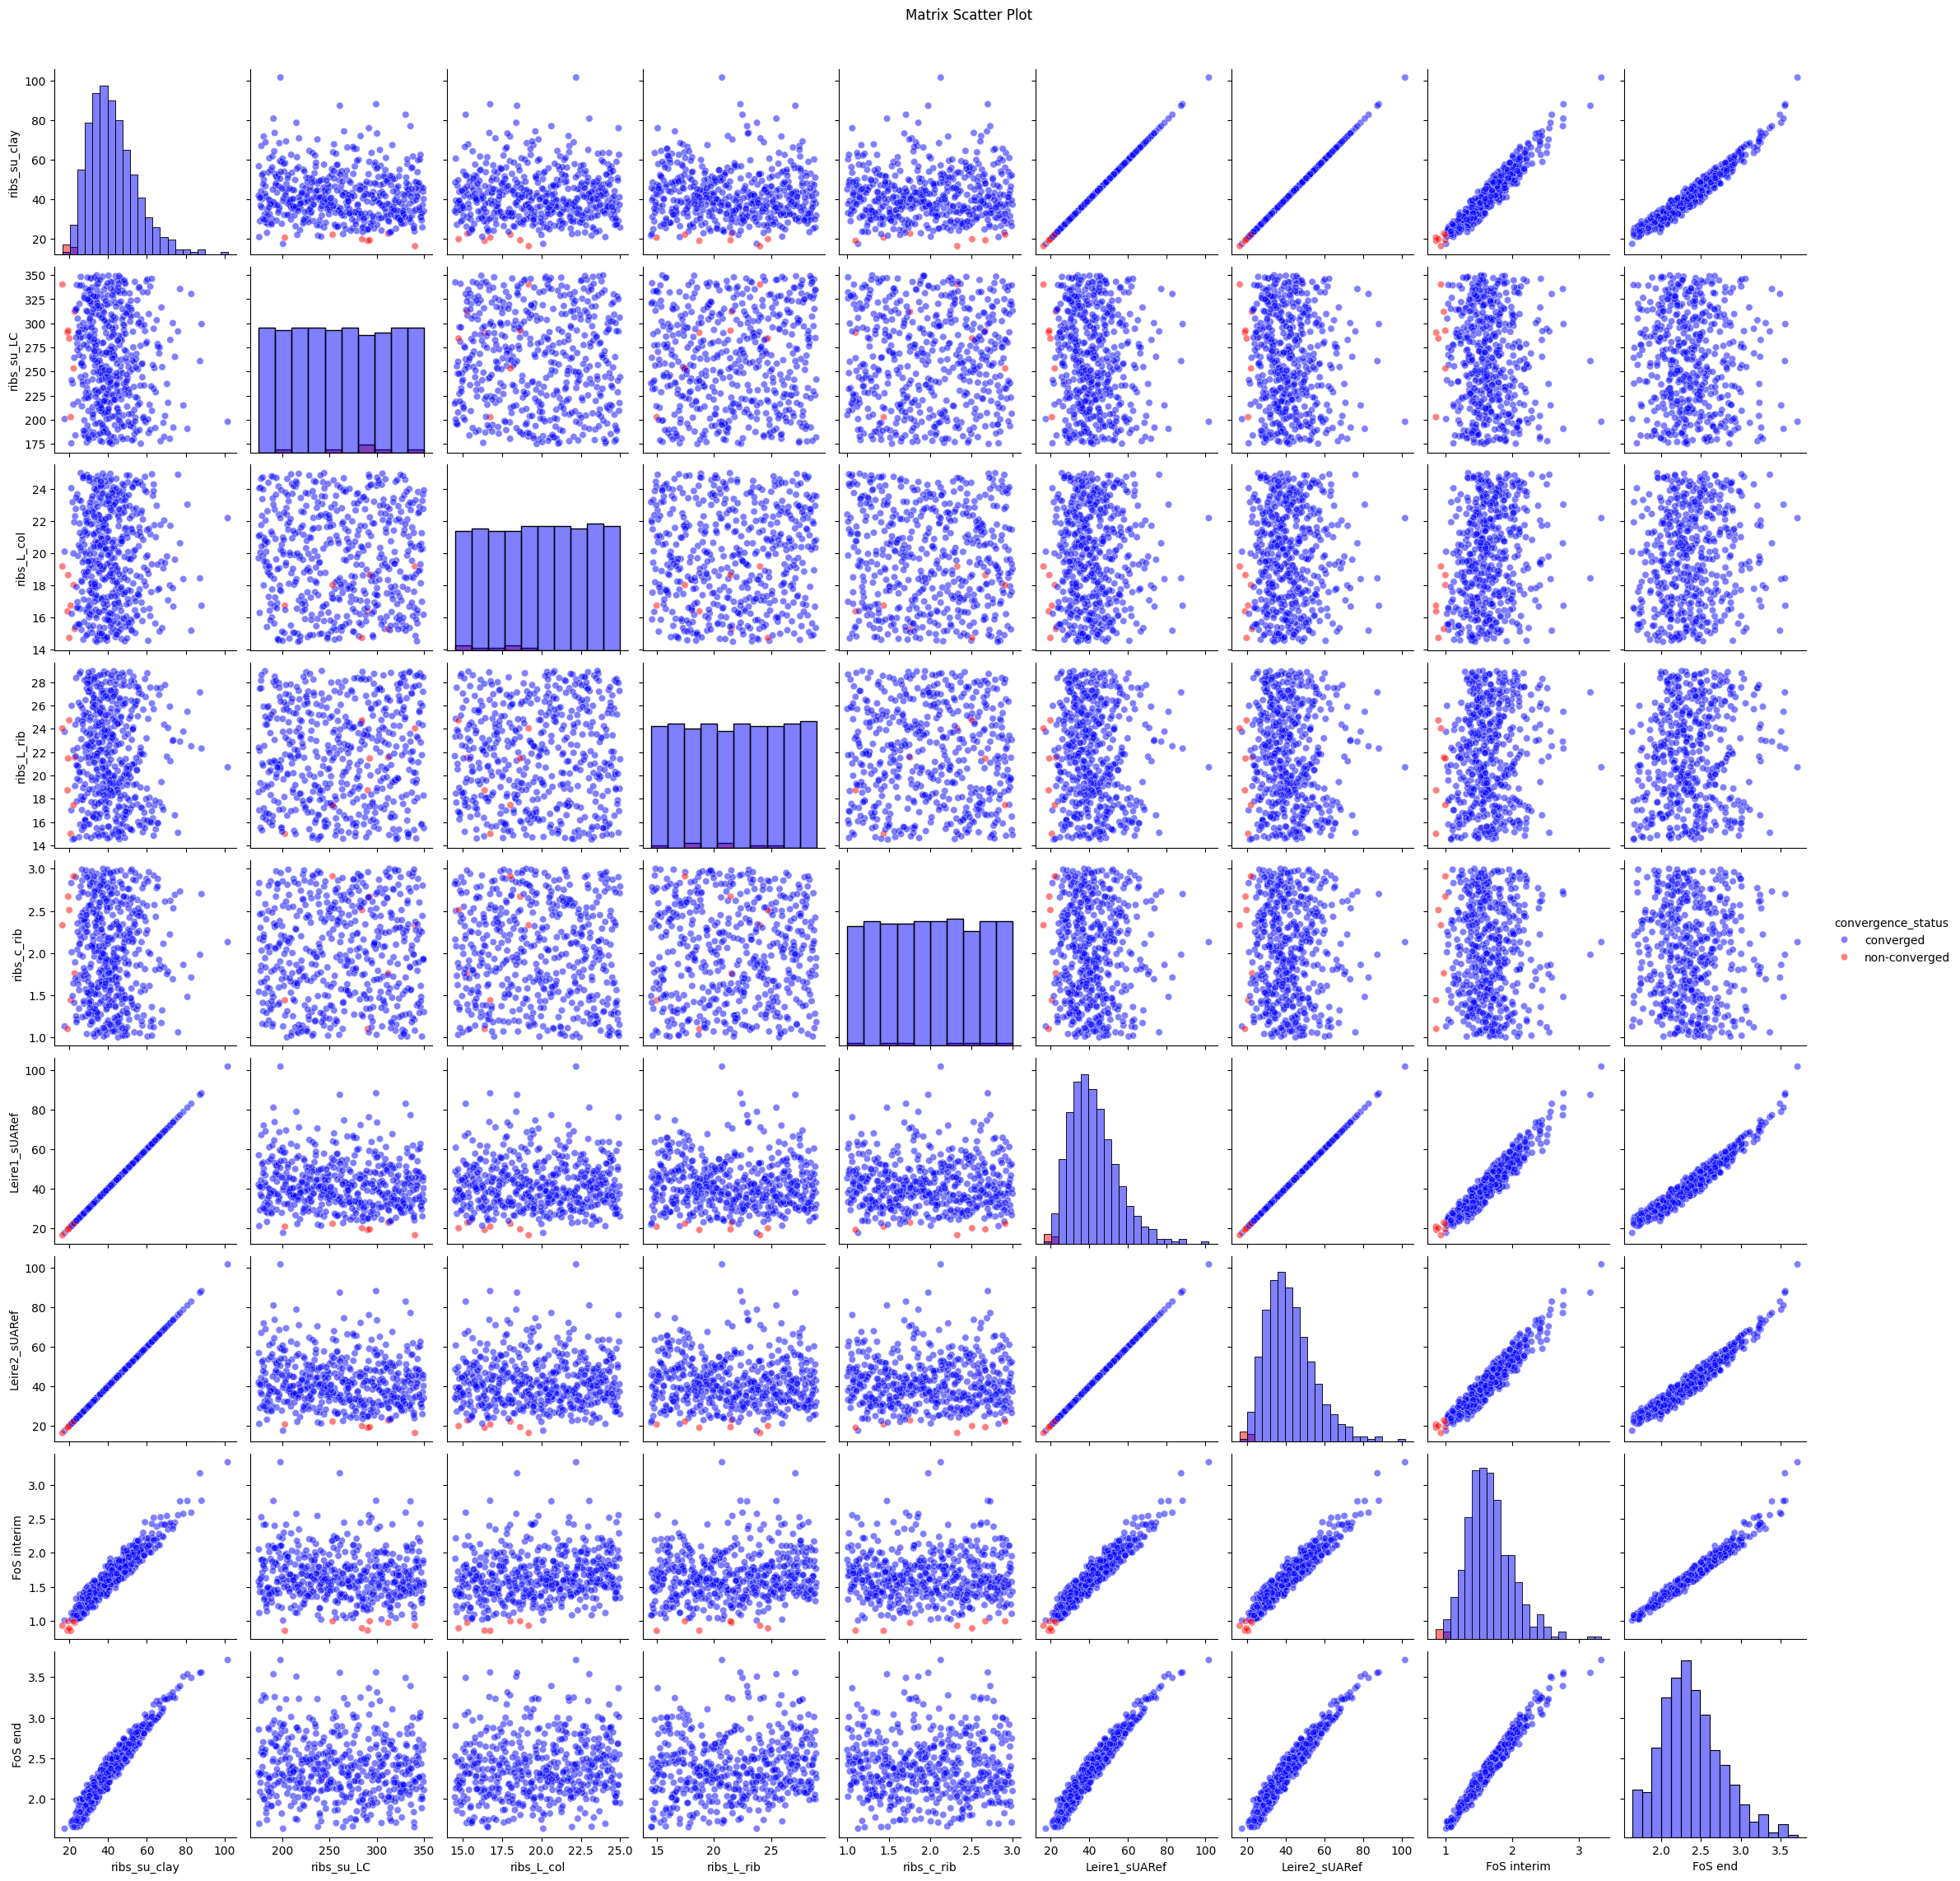

In [10]:
Combiner.analyse_corr(debug=True)

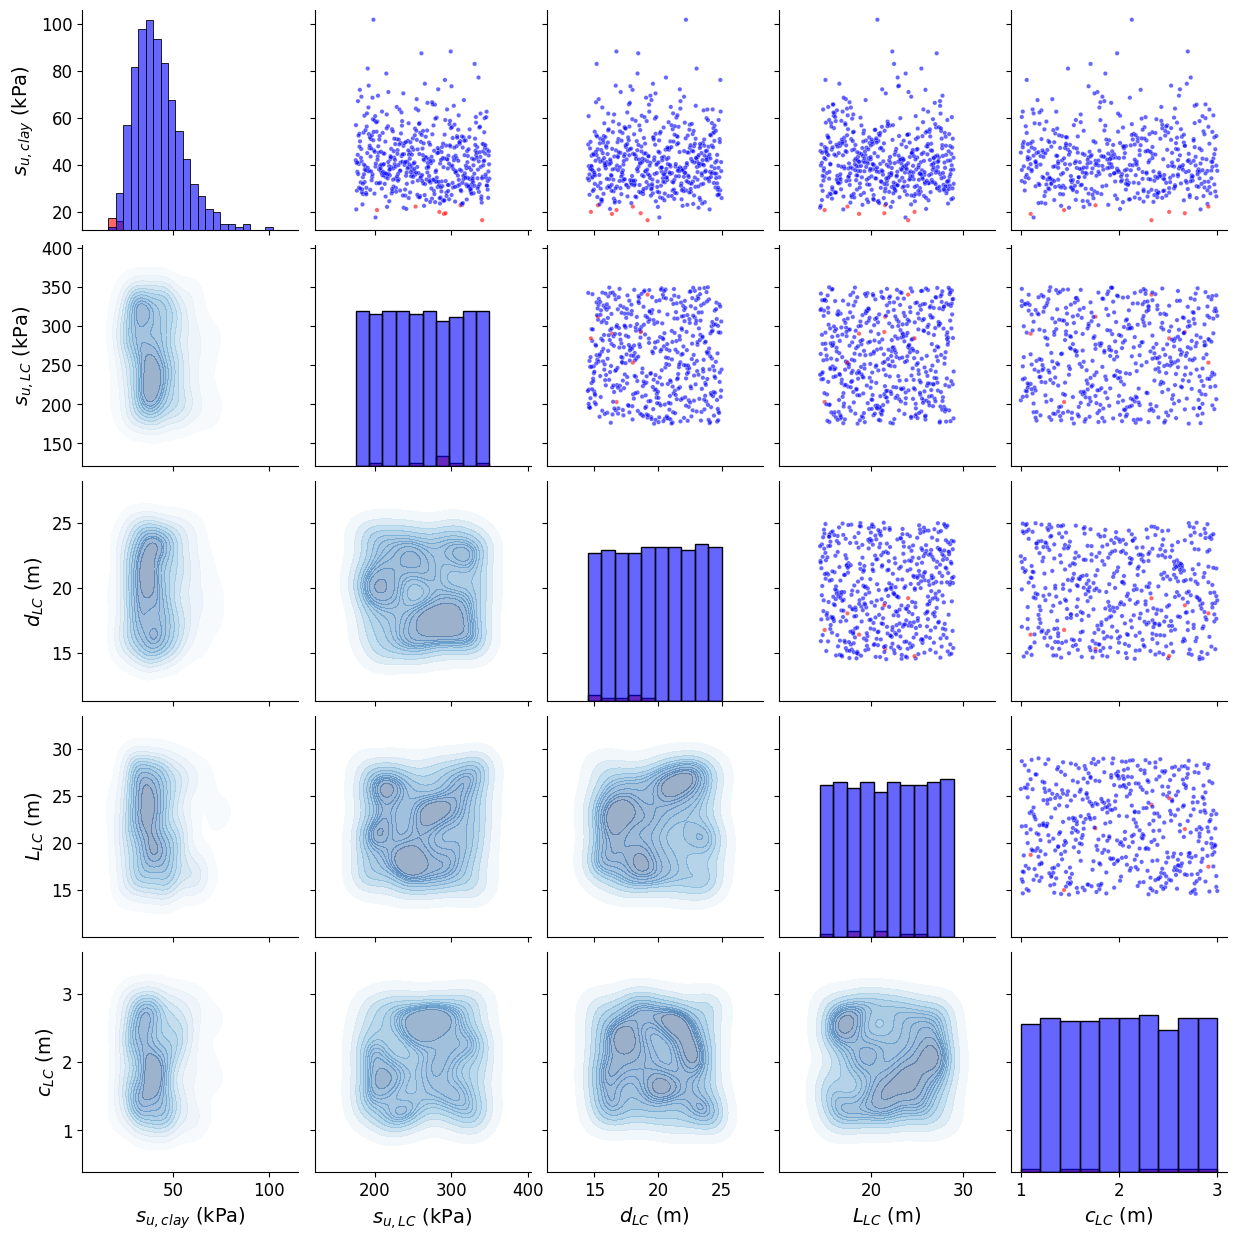

In [11]:
Combiner.plot_scatter_matrix(["$s_{u,clay}$ (kPa)","$s_{u,LC}$ (kPa)","$d_{LC}$ (m)","$L_{LC}$ (m)","$c_{LC}$ (m)"])